In [1]:
from matplotlib import pyplot as plt
from matplotlib import colors
import numpy as np
from matplotlib.patches import Path, PathPatch
import pandas as pd
from shapely.geometry import Point, shape, Polygon
from shapely.ops import unary_union, cascaded_union
from geopandas.tools import sjoin
import geopandas as gpd
from netCDF4 import Dataset
from cartopy import crs as ccrs
from cartopy.io.shapereader import Reader
from sklearn.metrics import mean_squared_error
import scipy.stats as st
from sklearn.linear_model import LinearRegression
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.ticker import FormatStrFormatter
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs

C:\Users\x12la\AppData\Local\Temp\ipykernel_33268\3062881070.py:8: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  from geopandas.tools import sjoin


In [2]:
# CMAQ lat/lon datafile
d03 = Dataset('C:/Users/x12la/Desktop/latlon_ChicagoLADCO_d03.nc')
cmaq_lon,cmaq_lat = np.array(d03['lon']),np.array(d03['lat'])
cmaq_llat,cmaq_ulat,cmaq_llon,cmaq_ulon=cmaq_lat.min(), cmaq_lat.max(), cmaq_lon.min(), cmaq_lon.max()

In [3]:
#CMAP 7 counties surrounding Chicago/Cook County
cmap_cty = gpd.read_file('C:/Users/x12la/Desktop/Scripts/CMAP_cty.shp')
cmap_cty = cmap_cty.to_crs('EPSG:4326')

#primary roads
primary_roads = gpd.read_file('C:/Users/x12la/Desktop/Scripts/tl_2016_us_primaryroads.shp')
primary_roads = primary_roads.to_crs('EPSG:4326')

In [4]:
base_aconc = gpd.read_file("COMBINE_ACONC_BASE_2023_annual.shp").to_crs("EPSG:4326")
base_o3    = gpd.read_file("dailymaxozone_base_2023_annual.shp").to_crs("EPSG:4326")

locus_aconc = gpd.read_file("COMBINE_ACONC_LOCUSIdling_HDVSpatial_2023_annual.shp").to_crs("EPSG:4326")
locus_o3    = gpd.read_file("dailymaxozone_LOCUSIdling_HDVSpatial_2023_annual.shp").to_crs("EPSG:4326")

In [5]:
cmap_domain = cmap_cty.geometry.unary_union

cmap_roads = gpd.clip(primary_roads.to_crs("EPSG:4326"), cmap_domain)

cmap_base_aconc  = gpd.clip(base_aconc, cmap_domain)
cmap_base_o3     = gpd.clip(base_o3, cmap_domain)
cmap_locus_aconc = gpd.clip(locus_aconc, cmap_domain)
cmap_locus_o3    = gpd.clip(locus_o3, cmap_domain)

<h1> Plot Differences EPA Default and LOCUS + HDV On-road Mod

C:\Users\x12la\AppData\Local\Temp\ipykernel_33268\1467981647.py:80: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap(cfg["cmap_name"])(
C:\Users\x12la\AppData\Local\Temp\ipykernel_33268\1467981647.py:153: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap("bwr")(
C:\Users\x12la\AppData\Local\Temp\ipykernel_33268\1467981647.py:159: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap("bwr")(


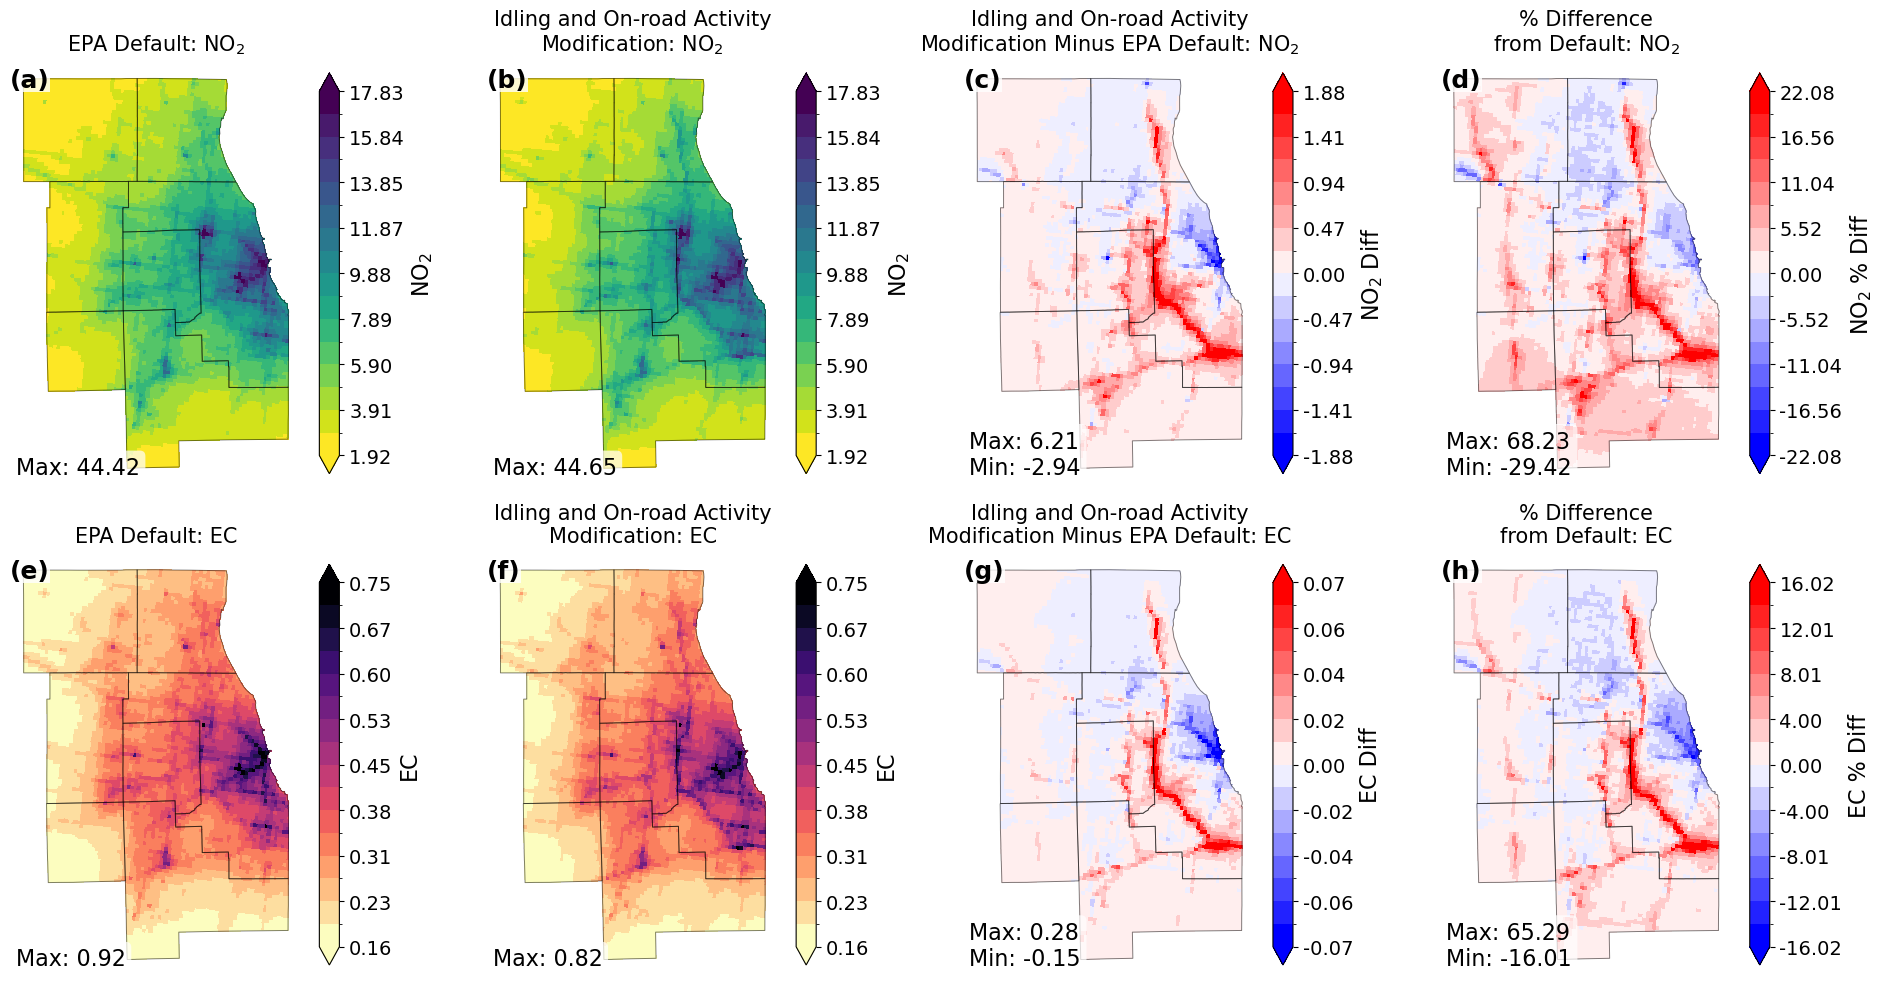

In [7]:
# ------------------------------------------------------------
# Plot annualized EPA Default vs LOCUS for NO2 and EC
# ------------------------------------------------------------

N_BINS = 16

pollutants = ["NO2", "PM25_EC"]

scenario_names = [
    "EPA Default",
    "Idling and On-road Activity\nModification",
    "Idling and On-road Activity\nModification Minus EPA Default",
    "% Difference\nfrom Default",
]

plot_config = {
    "NO2": {
        "cmap_name": "viridis_r",
        "title": "NO$_2$",
        "label": "NO$_2$",
        "column": "NO2",
    },
    "PM25_EC": {
        "cmap_name": "magma_r",
        "title": "EC",
        "label": "EC",
        "column": "PM25_EC",
    },
}

annual_gdfs_by_pol = {
    "NO2": {
        "reference": cmap_base_aconc,
        "scenario": cmap_locus_aconc,
    },
    "PM25_EC": {
        "reference": cmap_base_aconc,
        "scenario": cmap_locus_aconc,
    },
}


def plot_annual_default_locus():

    # --------------------------------------------------------
    # Define shared plotting styles for each pollutant
    # --------------------------------------------------------
    abs_styles = {}
    diff_styles = {}

    for pol in pollutants:

        cfg = plot_config[pol]
        col = cfg["column"]

        reference_gdf = annual_gdfs_by_pol[pol]["reference"]
        scenario_gdf = annual_gdfs_by_pol[pol]["scenario"]

        # ----------------------------------------------------
        # Absolute concentration plotting limits
        # ----------------------------------------------------
        vals_all = []

        for gdf in [reference_gdf, scenario_gdf]:

            vals = gdf[col].astype(float).to_numpy()
            vals = vals[np.isfinite(vals)]

            vals_all.append(vals)

        vals_all = np.concatenate(vals_all)

        vmin = np.quantile(vals_all, 0.001)
        vmax = np.quantile(vals_all, 0.999)

        if np.isclose(vmin, vmax):
            vmax = vmin + 1e-6

        cmap_disc = ListedColormap(
            plt.cm.get_cmap(cfg["cmap_name"])(
                np.linspace(0, 1, N_BINS)
            )
        )

        bounds = np.linspace(vmin, vmax, N_BINS + 1)

        norm = BoundaryNorm(
            bounds,
            cmap_disc.N,
        )

        abs_styles[pol] = {
            "bounds": bounds,
            "cmap": cmap_disc,
            "norm": norm,
        }

        # ----------------------------------------------------
        # Difference and percent-difference plotting limits
        # ----------------------------------------------------
        reference_vals = (
            reference_gdf[col]
            .astype(float)
            .to_numpy()
        )

        scenario_vals = (
            scenario_gdf[col]
            .astype(float)
            .to_numpy()
        )

        diff_vals = scenario_vals - reference_vals

        pct_vals = np.where(
            reference_vals != 0,
            (diff_vals / reference_vals) * 100.0,
            np.nan,
        )

        diff_vals_finite = diff_vals[np.isfinite(diff_vals)]
        pct_vals_finite = pct_vals[np.isfinite(pct_vals)]

        diff_lim = np.quantile(
            np.abs(diff_vals_finite),
            0.99,
        )

        pct_lim = np.quantile(
            np.abs(pct_vals_finite),
            0.99,
        )

        if np.isclose(diff_lim, 0):
            diff_lim = 1e-6

        if np.isclose(pct_lim, 0):
            pct_lim = 1e-6

        diff_bounds = np.linspace(
            -diff_lim,
            diff_lim,
            N_BINS + 1,
        )

        pct_bounds = np.linspace(
            -pct_lim,
            pct_lim,
            N_BINS + 1,
        )

        diff_cmap = ListedColormap(
            plt.cm.get_cmap("bwr")(
                np.linspace(0, 1, N_BINS)
            )
        )

        pct_cmap = ListedColormap(
            plt.cm.get_cmap("bwr")(
                np.linspace(0, 1, N_BINS)
            )
        )

        diff_styles[pol] = {
            "diff_bounds": diff_bounds,
            "diff_cmap": diff_cmap,
            "diff_norm": BoundaryNorm(
                diff_bounds,
                diff_cmap.N,
            ),
            "pct_bounds": pct_bounds,
            "pct_cmap": pct_cmap,
            "pct_norm": BoundaryNorm(
                pct_bounds,
                pct_cmap.N,
            ),
        }

    # --------------------------------------------------------
    # Create GeoDataFrames for each plotted scenario
    # --------------------------------------------------------
    scenario_gdfs_by_pol = {}

    for pol in pollutants:

        cfg = plot_config[pol]
        col = cfg["column"]

        reference_gdf = annual_gdfs_by_pol[pol]["reference"]
        scenario_gdf = annual_gdfs_by_pol[pol]["scenario"]

        plot_reference = reference_gdf.copy()
        plot_scenario = scenario_gdf.copy()
        plot_diff = scenario_gdf.copy()
        plot_pct = scenario_gdf.copy()

        ref_vals = reference_gdf[col].astype(float)
        scen_vals = scenario_gdf[col].astype(float)

        plot_reference[pol] = ref_vals

        plot_scenario[pol] = scen_vals

        plot_diff[pol] = (
            scen_vals - ref_vals
        )

        plot_pct[pol] = np.where(
            ref_vals != 0,
            (
                (scen_vals - ref_vals)
                / ref_vals
            )
            * 100.0,
            np.nan,
        )

        scenario_gdfs_by_pol[pol] = {
            scenario_names[0]: plot_reference,
            scenario_names[1]: plot_scenario,
            scenario_names[2]: plot_diff,
            scenario_names[3]: plot_pct,
        }

    # --------------------------------------------------------
    # Create the 2 x 4 figure
    # --------------------------------------------------------
    fig, axs = plt.subplots(
        nrows=2,
        ncols=4,
        figsize=(20, 10),
        subplot_kw={
            "projection": ccrs.PlateCarree()
        },
    )

    # --------------------------------------------------------
    # Plot each pollutant and scenario
    # --------------------------------------------------------
    for i, pol in enumerate(pollutants):

        for j, scen in enumerate(scenario_names):

            ax = axs[i, j]

            panel_label = (
                f"({chr(97 + i * 4 + j)})"
            )

            ax.text(
                0.001,
                0.98,
                panel_label,
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=18,
                fontweight="bold",
                bbox=dict(
                    facecolor="white",
                    alpha=0.8,
                    edgecolor="none",
                    pad=0.2,
                ),
                zorder=10,
            )

            gdf = scenario_gdfs_by_pol[pol][scen]

            # ------------------------------------------------
            # Select plotting style
            # ------------------------------------------------
            if j in [0, 1]:

                style = abs_styles[pol]

                cmap_disc = style["cmap"]
                norm = style["norm"]
                bounds = style["bounds"]

            elif j == 2:

                style = diff_styles[pol]

                cmap_disc = style["diff_cmap"]
                norm = style["diff_norm"]
                bounds = style["diff_bounds"]

            else:

                style = diff_styles[pol]

                cmap_disc = style["pct_cmap"]
                norm = style["pct_norm"]
                bounds = style["pct_bounds"]

            # ------------------------------------------------
            # Plot the gridded concentrations
            # ------------------------------------------------
            gdf.plot(
                column=pol,
                ax=ax,
                cmap=cmap_disc,
                norm=norm,
                edgecolor="none",
                antialiased=False,
            )

            # Plot CMAP county boundaries
            cmap_cty.boundary.plot(
                ax=ax,
                color="k",
                alpha=0.5,
                linewidth=0.7,
            )

            ax.set_title(
                f"{scen}: {plot_config[pol]['title']}",
                fontsize=15,
            )

            ax.set_axis_off()

            # ------------------------------------------------
            # Add color bar
            # ------------------------------------------------
            sm = plt.cm.ScalarMappable(
                norm=norm,
                cmap=cmap_disc,
            )

            sm._A = []

            cbar = fig.colorbar(
                sm,
                ax=ax,
                fraction=0.046,
                pad=0.04,
                boundaries=bounds,
                ticks=bounds[::2],
                spacing="proportional",
                extend="both",
            )

            cbar.ax.tick_params(
                labelsize=14
            )

            cbar.ax.yaxis.set_major_formatter(
                FormatStrFormatter("%.2f")
            )

            if j == 3:

                cbar.set_label(
                    f"{plot_config[pol]['label']} % Diff",
                    fontsize=16,
                )

            elif j == 2:

                cbar.set_label(
                    f"{plot_config[pol]['label']} Diff",
                    fontsize=16,
                )

            else:

                cbar.set_label(
                    plot_config[pol]["label"],
                    fontsize=16,
                )

            # ------------------------------------------------
            # Add minimum and maximum annotations
            # ------------------------------------------------
            vals = (
                gdf[pol]
                .astype(float)
                .to_numpy()
            )

            vals = vals[np.isfinite(vals)]

            vmax_panel = float(
                np.nanmax(vals)
            )

            vmin_panel = float(
                np.nanmin(vals)
            )

            if j in [0, 1]:

                annot_text = (
                    f"Max: {vmax_panel:.2f}"
                )

            else:

                annot_text = (
                    f"Max: {vmax_panel:.2f}\n"
                    f"Min: {vmin_panel:.2f}"
                )

            ax.text(
                0.02,
                0.02,
                annot_text,
                transform=ax.transAxes,
                ha="left",
                va="bottom",
                fontsize=16,
                color="black",
                bbox=dict(
                    facecolor="white",
                    alpha=0.7,
                    boxstyle="round,pad=0.25",
                    linewidth=0,
                ),
                zorder=10,
            )

    # --------------------------------------------------------
    # Save and display figure
    # --------------------------------------------------------
    plt.tight_layout()

    plt.savefig(
        "Fig_Annualized_Default_LOCUS_NO2_EC_2023.png",
        dpi=500,
        bbox_inches="tight",
    )

    plt.show()

plot_annual_default_locus()

C:\Users\x12la\AppData\Local\Temp\ipykernel_33268\791000696.py:76: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap(cfg["cmap_name"])(
C:\Users\x12la\AppData\Local\Temp\ipykernel_33268\791000696.py:153: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap("bwr")(
C:\Users\x12la\AppData\Local\Temp\ipykernel_33268\791000696.py:159: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap("bwr")(


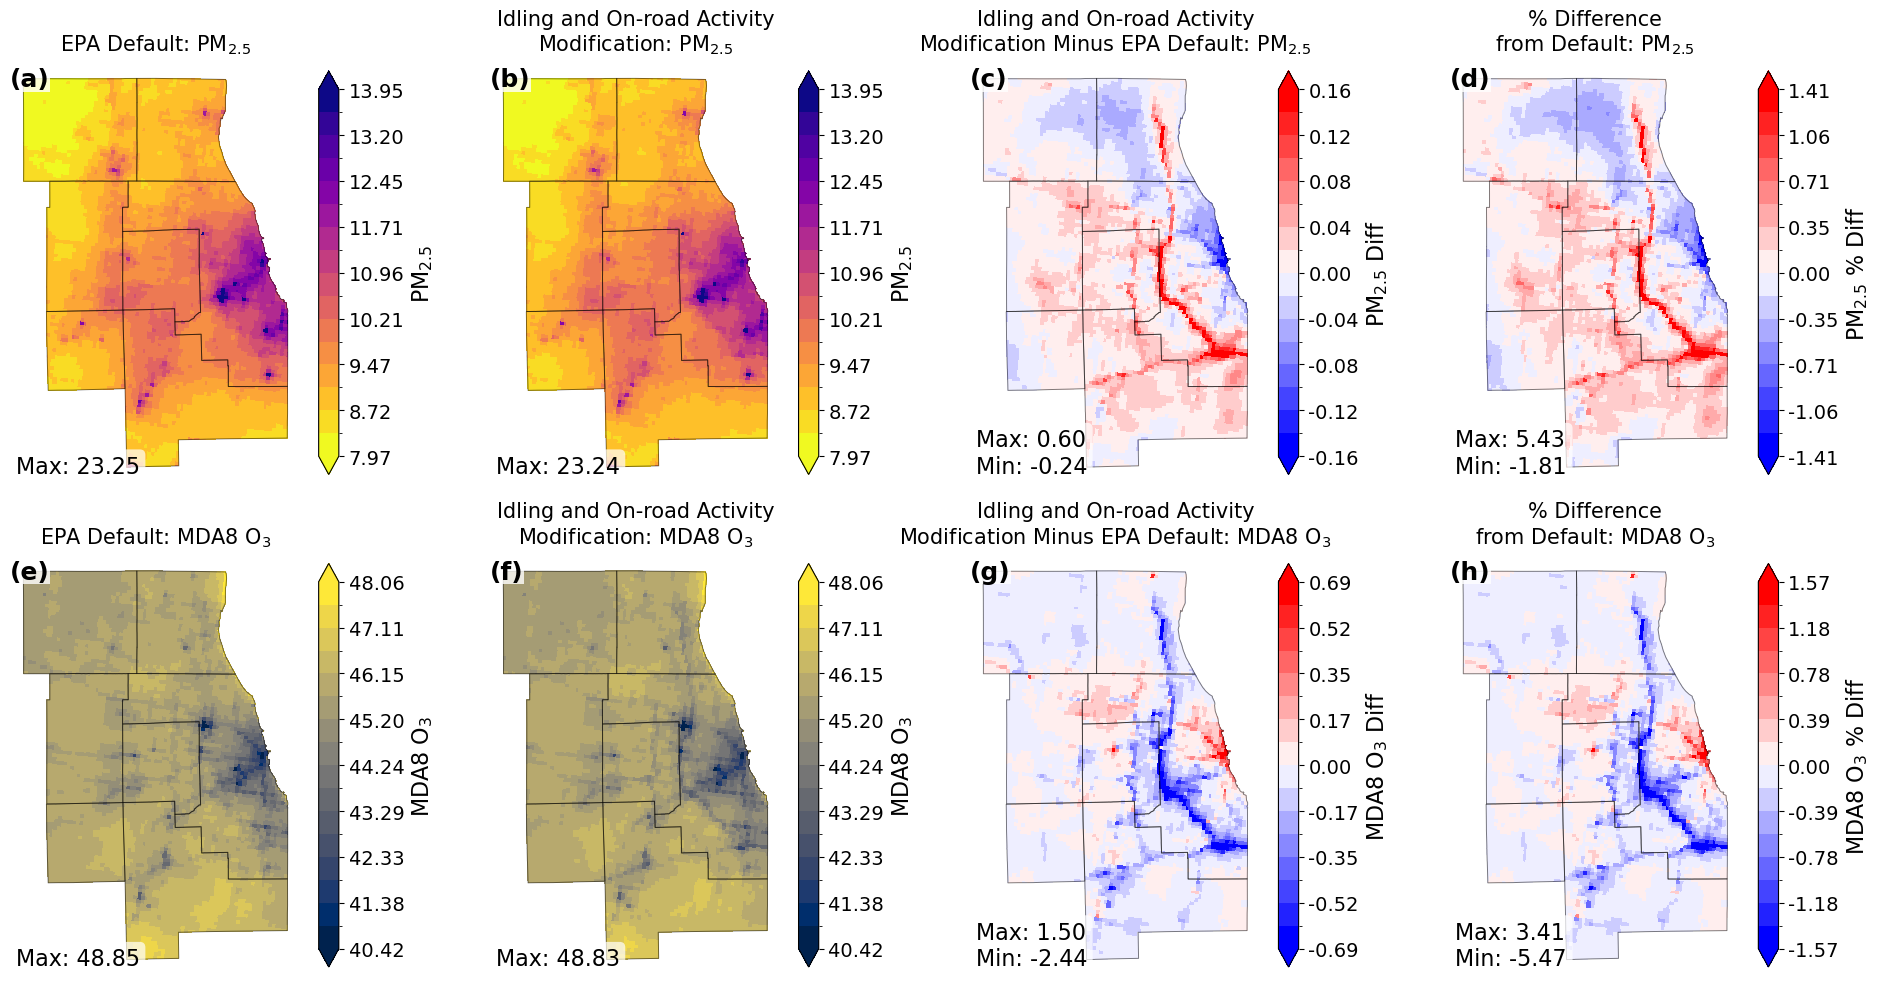

In [8]:
N_BINS = 16

pollutants = ["PM25_TOT", "O3"]

scenario_names = [
    "EPA Default",
    "Idling and On-road Activity\nModification",
    "Idling and On-road Activity\nModification Minus EPA Default",
    "% Difference\nfrom Default",
]

plot_config = {
    "PM25_TOT": {
        "cmap_name": "plasma_r",
        "title": "PM$_{2.5}$",
        "label": "PM$_{2.5}$",
        "column": "PM25_TOT",
    },
    "O3": {
        "cmap_name": "cividis",
        "title": "MDA8 O$_3$",
        "label": "MDA8 O$_3$",
        "column": "O3",
    },
}

annual_gdfs_by_pol = {
    "PM25_TOT": {
        "reference": cmap_base_aconc,
        "scenario": cmap_locus_aconc,
    },
    "O3": {
        "reference": cmap_base_o3,
        "scenario": cmap_locus_o3,
    },
}


def plot_annual_default_locus_pm25_o3():

    # --------------------------------------------------------
    # Define shared plotting styles for each pollutant
    # --------------------------------------------------------
    abs_styles = {}
    diff_styles = {}

    for pol in pollutants:

        cfg = plot_config[pol]
        col = cfg["column"]

        reference_gdf = annual_gdfs_by_pol[pol]["reference"]
        scenario_gdf = annual_gdfs_by_pol[pol]["scenario"]

        # ----------------------------------------------------
        # Absolute concentration plotting limits
        # ----------------------------------------------------
        vals_all = []

        for gdf in [reference_gdf, scenario_gdf]:

            vals = gdf[col].astype(float).to_numpy()
            vals = vals[np.isfinite(vals)]

            vals_all.append(vals)

        vals_all = np.concatenate(vals_all)

        vmin = np.quantile(vals_all, 0.001)
        vmax = np.quantile(vals_all, 0.999)

        if np.isclose(vmin, vmax):
            vmax = vmin + 1e-6

        cmap_disc = ListedColormap(
            plt.cm.get_cmap(cfg["cmap_name"])(
                np.linspace(0, 1, N_BINS)
            )
        )

        bounds = np.linspace(
            vmin,
            vmax,
            N_BINS + 1,
        )

        norm = BoundaryNorm(
            bounds,
            cmap_disc.N,
        )

        abs_styles[pol] = {
            "bounds": bounds,
            "cmap": cmap_disc,
            "norm": norm,
        }

        # ----------------------------------------------------
        # Difference and percent-difference plotting limits
        # ----------------------------------------------------
        reference_vals = (
            reference_gdf[col]
            .astype(float)
            .to_numpy()
        )

        scenario_vals = (
            scenario_gdf[col]
            .astype(float)
            .to_numpy()
        )

        diff_vals = scenario_vals - reference_vals

        pct_vals = np.where(
            reference_vals != 0,
            (diff_vals / reference_vals) * 100.0,
            np.nan,
        )

        diff_vals_finite = diff_vals[np.isfinite(diff_vals)]
        pct_vals_finite = pct_vals[np.isfinite(pct_vals)]

        diff_lim = np.quantile(
            np.abs(diff_vals_finite),
            0.99,
        )

        pct_lim = np.quantile(
            np.abs(pct_vals_finite),
            0.99,
        )

        if np.isclose(diff_lim, 0):
            diff_lim = 1e-6

        if np.isclose(pct_lim, 0):
            pct_lim = 1e-6

        diff_bounds = np.linspace(
            -diff_lim,
            diff_lim,
            N_BINS + 1,
        )

        pct_bounds = np.linspace(
            -pct_lim,
            pct_lim,
            N_BINS + 1,
        )

        diff_cmap = ListedColormap(
            plt.cm.get_cmap("bwr")(
                np.linspace(0, 1, N_BINS)
            )
        )

        pct_cmap = ListedColormap(
            plt.cm.get_cmap("bwr")(
                np.linspace(0, 1, N_BINS)
            )
        )

        diff_styles[pol] = {
            "diff_bounds": diff_bounds,
            "diff_cmap": diff_cmap,
            "diff_norm": BoundaryNorm(
                diff_bounds,
                diff_cmap.N,
            ),
            "pct_bounds": pct_bounds,
            "pct_cmap": pct_cmap,
            "pct_norm": BoundaryNorm(
                pct_bounds,
                pct_cmap.N,
            ),
        }

    # --------------------------------------------------------
    # Create GeoDataFrames for each plotted scenario
    # --------------------------------------------------------
    scenario_gdfs_by_pol = {}

    for pol in pollutants:

        cfg = plot_config[pol]
        col = cfg["column"]

        reference_gdf = annual_gdfs_by_pol[pol]["reference"]
        scenario_gdf = annual_gdfs_by_pol[pol]["scenario"]

        plot_reference = reference_gdf.copy()
        plot_scenario = scenario_gdf.copy()
        plot_diff = scenario_gdf.copy()
        plot_pct = scenario_gdf.copy()

        ref_vals = reference_gdf[col].astype(float)
        scen_vals = scenario_gdf[col].astype(float)

        plot_reference[pol] = ref_vals

        plot_scenario[pol] = scen_vals

        plot_diff[pol] = (
            scen_vals - ref_vals
        )

        plot_pct[pol] = np.where(
            ref_vals != 0,
            (
                (scen_vals - ref_vals)
                / ref_vals
            )
            * 100.0,
            np.nan,
        )

        scenario_gdfs_by_pol[pol] = {
            scenario_names[0]: plot_reference,
            scenario_names[1]: plot_scenario,
            scenario_names[2]: plot_diff,
            scenario_names[3]: plot_pct,
        }

    # --------------------------------------------------------
    # Create the 2 × 4 Supporting Information figure
    # --------------------------------------------------------
    fig, axs = plt.subplots(
        nrows=2,
        ncols=4,
        figsize=(20, 10),
        subplot_kw={
            "projection": ccrs.PlateCarree()
        },
    )

    # --------------------------------------------------------
    # Plot each pollutant and scenario
    # --------------------------------------------------------
    for i, pol in enumerate(pollutants):

        for j, scen in enumerate(scenario_names):

            ax = axs[i, j]

            panel_label = (
                f"({chr(97 + i * 4 + j)})"
            )

            ax.text(
                0.001,
                0.98,
                panel_label,
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=18,
                fontweight="bold",
                bbox=dict(
                    facecolor="white",
                    alpha=0.8,
                    edgecolor="none",
                    pad=0.2,
                ),
                zorder=10,
            )

            gdf = scenario_gdfs_by_pol[pol][scen]

            # ------------------------------------------------
            # Select plotting style
            # ------------------------------------------------
            if j in [0, 1]:

                style = abs_styles[pol]

                cmap_disc = style["cmap"]
                norm = style["norm"]
                bounds = style["bounds"]

            elif j == 2:

                style = diff_styles[pol]

                cmap_disc = style["diff_cmap"]
                norm = style["diff_norm"]
                bounds = style["diff_bounds"]

            else:

                style = diff_styles[pol]

                cmap_disc = style["pct_cmap"]
                norm = style["pct_norm"]
                bounds = style["pct_bounds"]

            # ------------------------------------------------
            # Plot the gridded concentrations
            # ------------------------------------------------
            gdf.plot(
                column=pol,
                ax=ax,
                cmap=cmap_disc,
                norm=norm,
                edgecolor="none",
                antialiased=False,
            )

            # Plot CMAP county boundaries
            cmap_cty.boundary.plot(
                ax=ax,
                color="k",
                alpha=0.5,
                linewidth=0.7,
            )

            ax.set_title(
                f"{scen}: {plot_config[pol]['title']}",
                fontsize=15,
            )

            ax.set_axis_off()

            # ------------------------------------------------
            # Add color bar
            # ------------------------------------------------
            sm = plt.cm.ScalarMappable(
                norm=norm,
                cmap=cmap_disc,
            )

            sm._A = []

            cbar = fig.colorbar(
                sm,
                ax=ax,
                fraction=0.046,
                pad=0.04,
                boundaries=bounds,
                ticks=bounds[::2],
                spacing="proportional",
                extend="both",
            )

            cbar.ax.tick_params(
                labelsize=14
            )

            cbar.ax.yaxis.set_major_formatter(
                FormatStrFormatter("%.2f")
            )

            if j == 3:

                cbar.set_label(
                    f"{plot_config[pol]['label']} % Diff",
                    fontsize=16,
                )

            elif j == 2:

                cbar.set_label(
                    f"{plot_config[pol]['label']} Diff",
                    fontsize=16,
                )

            else:

                cbar.set_label(
                    plot_config[pol]["label"],
                    fontsize=16,
                )

            # ------------------------------------------------
            # Add minimum and maximum annotations
            # ------------------------------------------------
            vals = (
                gdf[pol]
                .astype(float)
                .to_numpy()
            )

            vals = vals[np.isfinite(vals)]

            vmax_panel = float(
                np.nanmax(vals)
            )

            vmin_panel = float(
                np.nanmin(vals)
            )

            if j in [0, 1]:

                annot_text = (
                    f"Max: {vmax_panel:.2f}"
                )

            else:

                annot_text = (
                    f"Max: {vmax_panel:.2f}\n"
                    f"Min: {vmin_panel:.2f}"
                )

            ax.text(
                0.02,
                0.02,
                annot_text,
                transform=ax.transAxes,
                ha="left",
                va="bottom",
                fontsize=16,
                color="black",
                bbox=dict(
                    facecolor="white",
                    alpha=0.7,
                    boxstyle="round,pad=0.25",
                    linewidth=0,
                ),
                zorder=10,
            )

    # --------------------------------------------------------
    # Save and display figure
    # --------------------------------------------------------
    plt.tight_layout()

    plt.savefig(
        "Fig_SI_Annualized_Default_LOCUS_PM25_MDA8O3_2023.png",
        dpi=500,
        bbox_inches="tight",
    )

    plt.show()


plot_annual_default_locus_pm25_o3()